<a href="https://colab.research.google.com/github/whoiswasd/mineria/blob/main/Evaluacion_Lopez_Pohla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte A — El problema

* **Contexto:** El dataset contiene información sobre películas y series disponibles en Netflix, incluyendo su tipo, país, año de lanzamiento, clasificación, duración y género.
Este análisis podría ser utilizado por una plataforma de streaming o por un analista de contenido para conocer mejor las características y tendencias del catálogo.

* **Objetivo:** Analizar las características del catálogo de Netflix para identificar patrones entre el tipo de contenido, año de lanzamiento, país, clasificación y género, y determinar qué características permiten diferenciar las películas de las series.
* Por qué este problema se aborda con minería
de datos y no solo con una consulta o un promedio: Este problema se puede abordar con minería de datos porque no buscamos solamente contar películas o calcular un promedio. Queremos analizar varias características al mismo tiempo y descubrir patrones y relaciones entre las variables.
Para esto se utilizarán reglas de asociación y un árbol de decisión.


# Parte B — Los datos

**Importamos las librerías:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


**Subimos el CSV:**

In [2]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)

Saving netflix_titles.csv to netflix_titles.csv
Archivo seleccionado: netflix_titles.csv


**Cargamos el archivo con pandas:**

In [3]:
df = pd.read_csv(nombre_csv)
print("Dataset cargado correctamente")
df.head()

Dataset cargado correctamente


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
import pandas as pd
df = pd.read_csv(nombre_csv)
print("DataFrame 'df' recargado exitosamente.")

DataFrame 'df' recargado exitosamente.


**Revisamos la cantidad de filas y columnas:**

In [5]:
filas, columnas = df.shape
print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)

Cantidad de filas: 8807
Cantidad de columnas: 12


El dataset contiene 8.807 registros y 12 columnas, por lo que cumple con el tamaño solicitado para la evaluación. Cada fila representa una película o serie disponible en Netflix.

**Revisamos las primeras filas:**

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


Al observar las primeras filas se puede ver que cada registro corresponde a un contenido de Netflix. El dataset contiene tanto películas como series y entrega información sobre sus características, como país, año, clasificación, duración y género.

**Nombre:** Netflix Movies and TV Shows

**Archivo utilizado:** netflix_titles.csv

**Autor/publicador:** Anand Shaw

**Fuente:** Kaggle

**Licencia indicada en Kaggle:** CC0: Dominio público

**Enlace:**
https://www.kaggle.com/datasets/anandshaw2001/netflix-movies-and-tv-shows

**Diccionario de atributos:**

| Atributo | Tipo | Importancia para el análisis |
|---|---|---|
| `show_id` | Categórica / identificador | Permite identificar cada registro, aunque no aporta información para descubrir patrones. |
| `type` | Categórica | Indica si el contenido es una película o serie. Será nuestra variable objetivo para el árbol. |
| `title` | Categórica / texto | Permite identificar el nombre del contenido, aunque no será utilizada para modelar. |
| `director` | Categórica | Permite conocer quién dirigió el contenido y explorar posibles relaciones con otros atributos. |
| `cast` | Categórica / texto | Indica los actores participantes en cada contenido. |
| `country` | Categórica | Permite analizar cómo se distribuye el contenido según su país de producción. |
| `date_added` | Fecha | Permite conocer cuándo fue incorporado el contenido a Netflix. |
| `release_year` | Numérica | Permite analizar la antigüedad y evolución temporal del catálogo. |
| `rating` | Categórica | Indica la clasificación por edad del contenido. |
| `duration` | Categórica/texto | Indica minutos en películas y temporadas en series. |
| `listed_in` | Categórica | Contiene los géneros o categorías del contenido. |
| `description` | Texto | Entrega una descripción del contenido, aunque no será necesaria para los modelos principales. |

# Parte C — Exploración y preparación (EDA)

CRISP-DM:
Comprensión de los datos + Preparación de los datos.

**Estructura y tipos:**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


El dataset contiene principalmente variables de tipo object, debido a que gran parte de la información corresponde a categorías o texto.

La variable release_year es numérica y representa el año de lanzamiento del contenido.

Algunas columnas, como date_added y duration, necesitarán transformación si queremos analizarlas de manera numérica.

**Buscar valores nulos:**

In [9]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos

,cantidad_nulos,porcentaje_nulos
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


La columna con mayor cantidad de datos faltantes es director, con 2.634 valores nulos (29,91%). También existen valores faltantes importantes en country y cast. Esto representa un problema de calidad de datos, por lo que será necesario decidir qué columnas son realmente necesarias antes de entrenar los modelos.

**Revisamos los valores duplicados:**

In [10]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")

Filas duplicadas: 0
Porcentaje duplicado: 0.0  %


No se encontraron filas duplicadas, por lo que no fue necesario eliminar registros por este motivo. Esto evita el riesgo de que registros repetidos alteren las frecuencias utilizadas posteriormente en el análisis.

**Estadística descriptiva:**

In [11]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,"8,807.00",8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,014.18",NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.82,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,925.00",NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,013.00",NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,017.00",NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,019.00",NaN,NaN,NaN,NaN


La estadística descriptiva permite observar las características generales del dataset. Se puede ver que existen variables categóricas con diferentes cantidades de valores únicos y que release_year es una de las principales variables numéricas del dataset.

In [12]:
df["release_year"].describe()

,release_year
count,"8,807.00"
mean,"2,014.18"
std,8.82
min,"1,925.00"
25%,"2,013.00"
50%,"2,017.00"
75%,"2,019.00"
max,"2,021.00"


Los años de lanzamiento van desde 1925 hasta 2021. La mediana es 2017 y la media es aproximadamente 2014, lo que indica que gran parte del catálogo corresponde a producciones relativamente recientes. Esto también se puede observar posteriormente en la distribución gráfica de los años.

**Variable objetivo:**

Nuestra variable objetivo será: type

Porque tiene: Movie / TV Show

In [13]:
df["type"].value_counts()


,count
type,
Movie,6131
TV Show,2676


In [14]:
df["type"].value_counts(normalize=True) * 100

,proportion
type,
Movie,69.62
TV Show,30.38


La variable objetivo type contiene dos clases: Movie y TV Show. Se observa que una de las clases tiene una mayor cantidad de registros, por lo que existe cierto desbalance entre ambas categorías.

**Primer gráfico:**

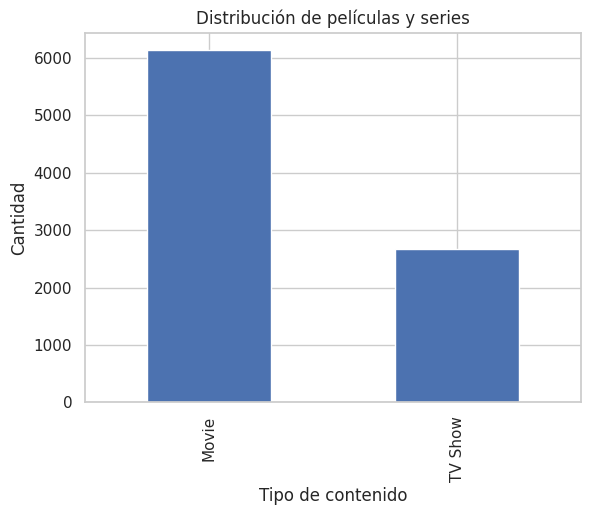

In [15]:
import matplotlib.pyplot as plt

df["type"].value_counts().plot(kind="bar")

plt.title("Distribución de películas y series")
plt.xlabel("Tipo de contenido")
plt.ylabel("Cantidad")
plt.show()

El gráfico muestra que existen más películas que series dentro del dataset. Por lo tanto, la variable objetivo no se encuentra distribuida de manera completamente equilibrada entre ambas clases.

**Segundo gráfico:**

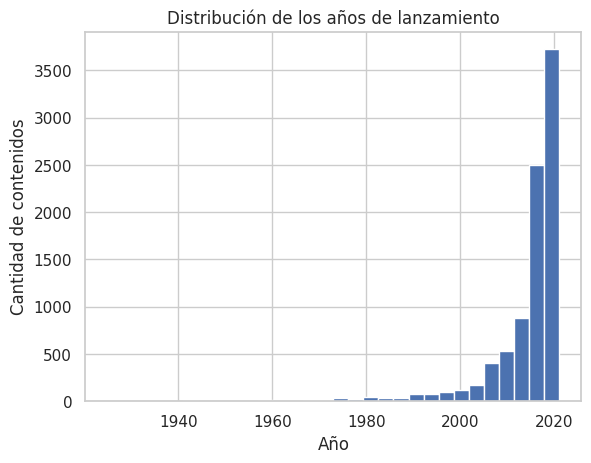

In [16]:
df["release_year"].plot(
    kind="hist",
    bins=30
)

plt.title("Distribución de los años de lanzamiento")
plt.xlabel("Año")
plt.ylabel("Cantidad de contenidos")
plt.show()

La distribución muestra que gran parte del contenido pertenece a años relativamente recientes, mientras que existen menos registros correspondientes a producciones antiguas.

**Problemas de calidad:**

Los principales problemas detectados son los valores nulos presentes en algunas variables y la existencia de columnas con demasiadas categorías diferentes. Además, algunas variables están almacenadas como texto y no pueden utilizarse directamente en ciertos algoritmos.
También se debe tener cuidado con duration, ya que sus valores permiten distinguir fácilmente películas y series: las películas utilizan minutos y las series temporadas. Utilizar esta variable directamente para predecir type podría entregar al árbol prácticamente la respuesta.

**Preparación de los datos y justificación:**

In [17]:

df_limpio = df.copy()

Creamos una copia para mantener los datos originales

In [18]:
df_limpio["country"] = df_limpio["country"].fillna("Desconocido")
df_limpio["rating"] = df_limpio["rating"].fillna("Desconocido")

print("Datos preparados correctamente")

Datos preparados correctamente


Completamos valores faltantes en variables que utilizaremos

**Transformar release_year:**

In [19]:
df_limpio["periodo"] = pd.cut(
    df_limpio["release_year"],
    bins=[1924, 1999, 2009, 2019, 2021],
    labels=[
        "Antes_2000",
        "2000_2009",
        "2010_2019",
        "2020_2021"
    ],
    include_lowest=True
)

df_limpio["periodo"].value_counts().sort_index()

,count
periodo,
Antes_2000,525
2000_2009,810
2010_2019,5927
2020_2021,1545


Se transformó release_year en períodos porque las reglas de asociación trabajan con ítems categóricos presentes o ausentes. De esta forma, un año específico como 2017 pasa a formar parte de la categoría 2010_2019, facilitando la búsqueda de patrones.

| Decisión | Justificación |
|---|---|
| No eliminar filas duplicadas | No se encontraron registros duplicados, por lo que no fue necesario realizar ninguna eliminación. |
| Completar nulos de `country` con `"Desconocido"` | Se conserva el registro sin inventar un país que no conocemos. |
| Completar nulos de `rating` con `"Desconocido"` | La clasificación es útil para el análisis, por lo que prefiero conservar los registros e identificar los datos faltantes. |
| Descartar `show_id` para el modelado | Es solamente un identificador único y no ayuda a encontrar patrones. |
| Descartar `title` para el modelado | El título identifica cada contenido, pero no es una característica útil para clasificar películas y series. |
| Descartar `description` para el modelado | Es texto libre y requeriría técnicas adicionales de procesamiento de lenguaje que no son necesarias para este análisis. |
| No utilizar `director` y `cast` en los modelos principales | Tienen muchas categorías diferentes y valores faltantes, lo que dificulta utilizarlas directamente en este análisis. |
| Transformar `release_year` en rangos | Las reglas de asociación trabajan con ítems presentes o ausentes, por lo que necesitamos convertir el año numérico en categorías. |
| No utilizar `duration` directamente en el árbol | La duración revela casi directamente si el contenido es una película (`min`) o serie (`Season`), lo que podría hacer que el árbol aprenda la respuesta sin descubrir un patrón útil. |

# Parte D — Reglas de asociación

**Fase CRISP-DM: Modelado**

Para las reglas de asociación seleccioné las variables type, country, rating, release_year y listed_in.
Elegí estas variables porque representan características importantes del contenido: si es película o serie, país, clasificación por edad, período de lanzamiento y género. Esto permitirá buscar relaciones entre las características del catálogo.
release_year es numérica, por lo que no se puede utilizar directamente como un ítem presente o ausente. Por esta razón se transformará en rangos llamados periodo.

**Preparar los datos:**

In [20]:
df_limpio = df.copy()

# Tratamiento de nulos de variables que utilizaremos
df_limpio["country"] = df_limpio["country"].fillna("Desconocido")
df_limpio["rating"] = df_limpio["rating"].fillna("Desconocido")

# Convertir el año numérico en períodos
df_limpio["periodo"] = pd.cut(
    df_limpio["release_year"],
    bins=[1924, 1999, 2009, 2019, 2021],
    labels=[
        "Antes_2000",
        "2000_2009",
        "2010_2019",
        "2020_2021"
    ],
    include_lowest=True
)

df_limpio[["type", "country", "rating", "release_year", "periodo", "listed_in"]].head()

,type,country,rating,release_year,periodo,listed_in
0,Movie,United States,PG-13,2020,2020_2021,Documentaries
1,TV Show,South Africa,TV-MA,2021,2020_2021,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Desconocido,TV-MA,2021,2020_2021,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Desconocido,TV-MA,2021,2020_2021,"Docuseries, Reality TV"
4,TV Show,India,TV-MA,2021,2020_2021,"International TV Shows, Romantic TV Shows, TV ..."


Se creó una copia del dataset para mantener los datos originales. Los valores faltantes de country y rating fueron reemplazados por Desconocido, evitando eliminar registros o inventar información.
También se transformó release_year en períodos. Esto es necesario porque las reglas de asociación trabajan con ítems categóricos presentes o ausentes, no con una variable numérica continua.

**Creamos las transacciones:**


In [21]:
transacciones = []

for _, fila in df_limpio.iterrows():

    items = [
        "Tipo=" + str(fila["type"]),
        "Pais=" + str(fila["country"]),
        "Rating=" + str(fila["rating"]),
        "Periodo=" + str(fila["periodo"])
    ]

    # Separar los géneros de listed_in
    generos = str(fila["listed_in"]).split(",")

    for genero in generos:
        items.append("Genero=" + genero.strip())

    transacciones.append(items)

# Mostrar las primeras 3 transacciones
transacciones[:3]

[['Tipo=Movie',
  'Pais=United States',
  'Rating=PG-13',
  'Periodo=2020_2021',
  'Genero=Documentaries'],
 ['Tipo=TV Show',
  'Pais=South Africa',
  'Rating=TV-MA',
  'Periodo=2020_2021',
  'Genero=International TV Shows',
  'Genero=TV Dramas',
  'Genero=TV Mysteries'],
 ['Tipo=TV Show',
  'Pais=Desconocido',
  'Rating=TV-MA',
  'Periodo=2020_2021',
  'Genero=Crime TV Shows',
  'Genero=International TV Shows',
  'Genero=TV Action & Adventure']]

Cada fila del dataset fue transformada en una transacción compuesta por distintos ítems. Los géneros de listed_in fueron separados porque un contenido puede pertenecer a más de un género. De esta manera, cada género puede aparecer individualmente en las reglas.

**Transformamos a presencia/ausencia:**

In [23]:
!pip install mlxtend -q

In [24]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()

matriz = te.fit(transacciones).transform(transacciones)

df_transacciones = pd.DataFrame(
    matriz,
    columns=te.columns_
)

df_transacciones.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Genero=Action & Adventure,Genero=Anime Features,Genero=Anime Series,Genero=British TV Shows,Genero=Children & Family Movies,Genero=Classic & Cult TV,Genero=Classic Movies,Genero=Comedies,Genero=Crime TV Shows,Genero=Cult Movies,Genero=Documentaries,Genero=Docuseries,Genero=Dramas,Genero=Faith & Spirituality,Genero=Horror Movies,Genero=Independent Movies,Genero=International Movies,Genero=International TV Shows,Genero=Kids' TV,Genero=Korean TV Shows,Genero=LGBTQ Movies,Genero=Movies,Genero=Music & Musicals,Genero=Reality TV,Genero=Romantic Movies,...,Pais=Zimbabwe,Periodo=2000_2009,Periodo=2010_2019,Periodo=2020_2021,Periodo=Antes_2000,Rating=66 min,Rating=74 min,Rating=84 min,Rating=Desconocido,Rating=G,Rating=NC-17,Rating=NR,Rating=PG,Rating=PG-13,Rating=R,Rating=TV-14,Rating=TV-G,Rating=TV-MA,Rating=TV-PG,Rating=TV-Y,Rating=TV-Y7,Rating=TV-Y7-FV,Rating=UR,Tipo=Movie,Tipo=TV Show
0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Las transacciones fueron convertidas a una matriz booleana. True significa que un ítem está presente en el registro y False que está ausente. Este es el formato que necesita el algoritmo Apriori para encontrar combinaciones frecuentes.

**Generamos conjuntos frecuentes y reglas:**

Primera prueba

In [25]:
frecuentes_1 = apriori(
    df_transacciones,
    min_support=0.05,
    use_colnames=True
)

reglas_1 = association_rules(
    frecuentes_1,
    metric="confidence",
    min_threshold=0.50
)

print("Conjuntos frecuentes:", len(frecuentes_1))
print("Reglas encontradas:", len(reglas_1))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Conjuntos frecuentes: 157
Reglas encontradas: 240


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Segunda prueba

In [26]:
frecuentes_2 = apriori(
    df_transacciones,
    min_support=0.03,
    use_colnames=True
)

reglas_2 = association_rules(
    frecuentes_2,
    metric="confidence",
    min_threshold=0.60
)

print("Conjuntos frecuentes:", len(frecuentes_2))
print("Reglas encontradas:", len(reglas_2))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Conjuntos frecuentes: 308
Reglas encontradas: 388


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

¿Por qué estos parámetros?

En la primera prueba, utilizando un support mínimo de 0,05 y una confidence mínima de 0,50, se obtuvieron 157 conjuntos frecuentes y 240 reglas.
En la segunda prueba se disminuyó el support a 0,03 y se aumentó la confidence a 0,60, obteniendo 308 conjuntos frecuentes y 388 reglas.

Al disminuir el support se pudieron considerar combinaciones que aparecen con menor frecuencia en el dataset, por lo que aumentó la cantidad de conjuntos frecuentes. Aunque se aumentó la confidence mínima, la mayor cantidad de conjuntos disponibles permitió obtener también una mayor cantidad de reglas, pasando de 240 a 388.

**Ver las reglas:**

**Support:** indica qué tan frecuente aparece la combinación en todo el dataset.

**Confidence:** indica qué tan frecuentemente aparece el consecuente cuando aparece el antecedente.

**Lift:** indica qué tan fuerte es la relación entre ambos. Un lift mayor que 1 indica una asociación positiva; cercano a 1 indica poca relación adicional.

In [27]:
reglas_mostrar = reglas_2[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    by="lift",
    ascending=False
)

reglas_mostrar.head(10)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,antecedents,consequents,support,confidence,lift
95,(Genero=Crime TV Shows),"(Tipo=TV Show, Rating=TV-MA)",0.04,0.74,5.73
24,(Genero=Romantic TV Shows),(Genero=International TV Shows),0.04,0.85,5.55
168,"(Tipo=TV Show, Genero=Romantic TV Shows)",(Genero=International TV Shows),0.04,0.85,5.55
169,(Genero=Romantic TV Shows),"(Genero=International TV Shows, Tipo=TV Show)",0.04,0.85,5.55
171,"(Periodo=2010_2019, Genero=TV Dramas)",(Genero=International TV Shows),0.04,0.70,4.59
337,"(Periodo=2010_2019, Genero=TV Dramas)","(Genero=International TV Shows, Tipo=TV Show)",0.04,0.70,4.59
334,"(Genero=TV Dramas, Periodo=2010_2019, Tipo=TV ...",(Genero=International TV Shows),0.04,0.70,4.59
343,"(Rating=TV-14, Periodo=2010_2019, Tipo=TV Show)",(Genero=International TV Shows),0.04,0.68,4.45
340,"(Genero=TV Dramas, Rating=TV-MA)","(Genero=International TV Shows, Tipo=TV Show)",0.03,0.68,4.43
339,"(Genero=TV Dramas, Tipo=TV Show, Rating=TV-MA)",(Genero=International TV Shows),0.03,0.68,4.43


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

| Regla | Support | Confidence | Lift | ¿Qué significa? | Decisión que podría apoyar |
|---|---:|---:|---:|---|---|
| Crime TV Shows → TV Show y TV-MA | 0,04 | 0,74 | 5,73 | Entre los contenidos clasificados como Crime TV Shows, un 74% también corresponde a TV Show y tiene clasificación TV-MA. La asociación es fuerte porque el lift es 5,73. | Puede ayudar a identificar qué clasificación aparece frecuentemente asociada a las series de crimen del catálogo. |
| Romantic TV Shows → International TV Shows | 0,04 | 0,85 | 5,55 | Un 85% de los contenidos que aparecen como Romantic TV Shows también aparecen como International TV Shows. El lift de 5,55 muestra una asociación positiva fuerte. | Puede apoyar el análisis de categorías que suelen aparecer juntas al organizar o estudiar el catálogo. |
| TV Dramas + período 2010–2019 → International TV Shows | 0,04 | 0,70 | 4,59 | Entre los TV Dramas del período 2010–2019, un 70% también aparece como International TV Shows. El lift de 4,59 indica una asociación positiva. | Puede ayudar a identificar relaciones entre período de lanzamiento y géneros de series internacionales. |

Las tres reglas presentan un lift mayor que 1, por lo que muestran asociaciones positivas entre sus elementos. La segunda regla presenta la mayor confidence de las seleccionadas (0,85), mientras que la primera presenta el mayor lift (5,73). Esto demuestra que las reglas de asociación permiten encontrar relaciones entre características del catálogo que no se observan solamente contando registros.

# Parte E — Árbol de decisión

**Fase CRISP-DM: Modelado**

**Variable objetivo:**

La variable objetivo seleccionada es type, que contiene dos clases: Movie y TV Show.
Se eligió porque es una variable categórica de dos clases y permite analizar qué características del contenido ayudan a diferenciar películas de series.

**Descartar variables:**

Para entrenar el árbol no se utilizarán show_id, title y description, porque corresponden a identificadores o textos que no representan características generales útiles para este análisis.
Tampoco se utilizarán director y cast porque presentan muchas categorías diferentes y valores faltantes.
Finalmente, se descartará duration porque está demasiado relacionada con la variable objetivo. Las películas tienen valores expresados en minutos y las series en temporadas, por lo que el árbol podría identificar type prácticamente de forma directa.

Este problema se puede detectar revisando las categorías y observando si una variable contiene información que permite conocer casi directamente la clase objetivo. En este caso, al revisar duration, se observa que sus unidades cambian según type.

**Variables del árbol:**

In [28]:
columnas_arbol = [
    "release_year",
    "rating",
    "country"
]

X = df_limpio[columnas_arbol].copy()
y = df_limpio["type"]

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [29]:
X = pd.get_dummies(
    X,
    columns=["rating", "country"],
    drop_first=False
)

X.head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,release_year,rating_66 min,rating_74 min,rating_84 min,rating_Desconocido,rating_G,rating_NC-17,rating_NR,rating_PG,rating_PG-13,rating_R,rating_TV-14,rating_TV-G,rating_TV-MA,rating_TV-PG,rating_TV-Y,rating_TV-Y7,rating_TV-Y7-FV,rating_UR,"country_, France, Algeria","country_, South Korea",country_Argentina,"country_Argentina, Brazil, France, Poland, Germany, Denmark","country_Argentina, Chile","country_Argentina, Chile, Peru",...,"country_United States, United Kingdom, Denmark, Sweden","country_United States, United Kingdom, France","country_United States, United Kingdom, France, Germany, Japan","country_United States, United Kingdom, Germany","country_United States, United Kingdom, Germany, Hungary","country_United States, United Kingdom, India","country_United States, United Kingdom, Italy","country_United States, United Kingdom, Japan","country_United States, United Kingdom, Morocco","country_United States, United Kingdom, New Zealand","country_United States, United Kingdom, Spain, South Korea","country_United States, Uruguay","country_United States, Venezuela",country_Uruguay,"country_Uruguay, Argentina","country_Uruguay, Argentina, Germany, Spain","country_Uruguay, Argentina, Spain","country_Uruguay, Germany","country_Uruguay, Guatemala","country_Uruguay, Spain, Mexico",country_Venezuela,"country_Venezuela, Colombia",country_Vietnam,country_West Germany,country_Zimbabwe
0,2020,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2021,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2021,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,2021,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2021,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

rating y country son variables categóricas, por lo que fueron transformadas a variables binarias mediante codificación one-hot. release_year se mantuvo como variable numérica para el árbol, ya que este algoritmo sí puede trabajar directamente con variables numéricas.

**Separar los datos:**

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Registros de entrenamiento:", len(X_train))
print("Registros de prueba:", len(X_test))

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Registros de entrenamiento: 7045
Registros de prueba: 1762


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Entrenar árbol con profundidad 4:**

In [31]:
from sklearn.tree import DecisionTreeClassifier

arbol = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

arbol.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

DecisionTreeClassifier(max_depth=4, random_state=42)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Gráfico del árbol:**

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

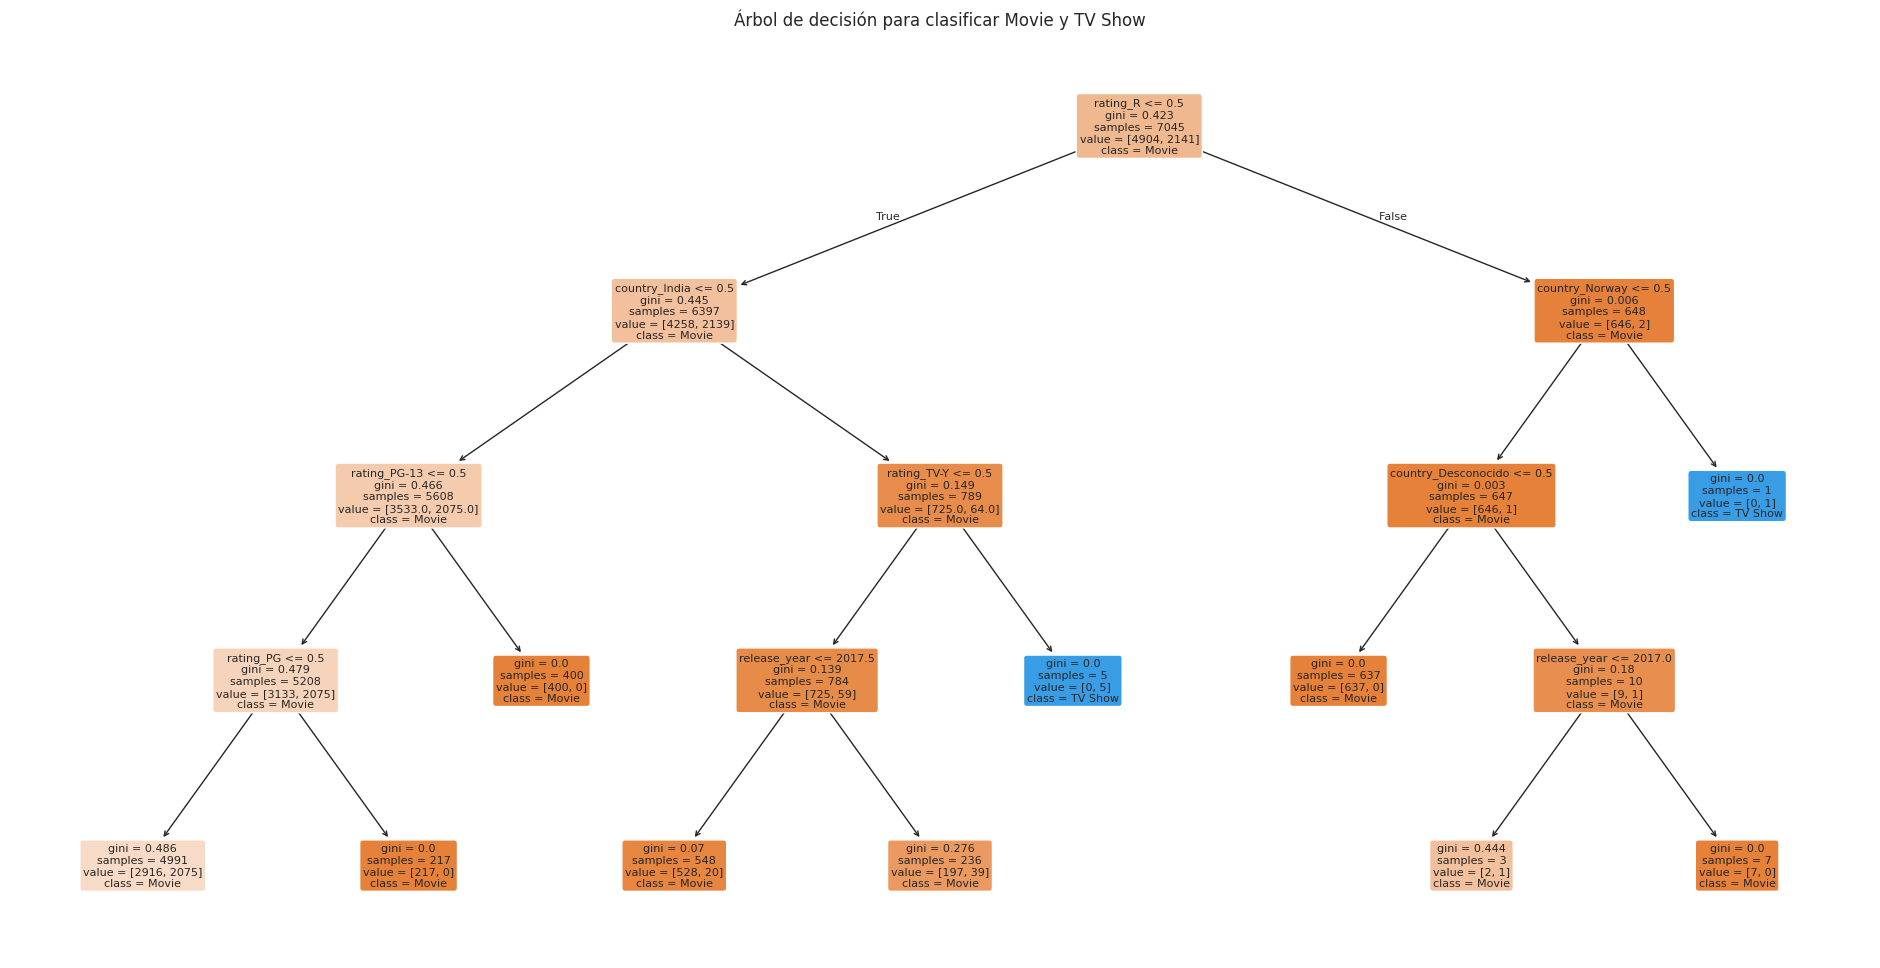

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 12))

plot_tree(
    arbol,
    feature_names=X.columns,
    class_names=arbol.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol de decisión para clasificar Movie y TV Show")
plt.show()

**Reglas en texto:**

In [33]:
from sklearn.tree import export_text

reglas_arbol = export_text(
    arbol,
    feature_names=list(X.columns)
)

print(reglas_arbol)

|--- rating_R <= 0.50
|   |--- country_India <= 0.50
|   |   |--- rating_PG-13 <= 0.50
|   |   |   |--- rating_PG <= 0.50
|   |   |   |   |--- class: Movie
|   |   |   |--- rating_PG >  0.50
|   |   |   |   |--- class: Movie
|   |   |--- rating_PG-13 >  0.50
|   |   |   |--- class: Movie
|   |--- country_India >  0.50
|   |   |--- rating_TV-Y <= 0.50
|   |   |   |--- release_year <= 2017.50
|   |   |   |   |--- class: Movie
|   |   |   |--- release_year >  2017.50
|   |   |   |   |--- class: Movie
|   |   |--- rating_TV-Y >  0.50
|   |   |   |--- class: TV Show
|--- rating_R >  0.50
|   |--- country_Norway <= 0.50
|   |   |--- country_Desconocido <= 0.50
|   |   |   |--- class: Movie
|   |   |--- country_Desconocido >  0.50
|   |   |   |--- release_year <= 2017.00
|   |   |   |   |--- class: Movie
|   |   |   |--- release_year >  2017.00
|   |   |   |   |--- class: Movie
|   |--- country_Norway >  0.50
|   |   |--- class: TV Show



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Identificar la raíz:**

In [34]:
atributo_raiz = X.columns[arbol.tree_.feature[0]]

print("Atributo de la raíz:", atributo_raiz)

Atributo de la raíz: rating_R


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

El atributo ubicado en la raíz es rating_R. El árbol lo seleccionó como primera división porque, dentro de las variables utilizadas, fue la que permitió separar mejor las clases Movie y TV Show en ese punto.

**Dos caminos raíz → hoja:**

In [35]:
print(reglas_arbol)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

|--- rating_R <= 0.50
|   |--- country_India <= 0.50
|   |   |--- rating_PG-13 <= 0.50
|   |   |   |--- rating_PG <= 0.50
|   |   |   |   |--- class: Movie
|   |   |   |--- rating_PG >  0.50
|   |   |   |   |--- class: Movie
|   |   |--- rating_PG-13 >  0.50
|   |   |   |--- class: Movie
|   |--- country_India >  0.50
|   |   |--- rating_TV-Y <= 0.50
|   |   |   |--- release_year <= 2017.50
|   |   |   |   |--- class: Movie
|   |   |   |--- release_year >  2017.50
|   |   |   |   |--- class: Movie
|   |   |--- rating_TV-Y >  0.50
|   |   |   |--- class: TV Show
|--- rating_R >  0.50
|   |--- country_Norway <= 0.50
|   |   |--- country_Desconocido <= 0.50
|   |   |   |--- class: Movie
|   |   |--- country_Desconocido >  0.50
|   |   |   |--- release_year <= 2017.00
|   |   |   |   |--- class: Movie
|   |   |   |--- release_year >  2017.00
|   |   |   |   |--- class: Movie
|   |--- country_Norway >  0.50
|   |   |--- class: TV Show



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Camino 1:**
Si el contenido no tiene clasificación R, no corresponde a India y tiene clasificación PG-13, el árbol lo clasifica como Movie.

**Interpretación de negocio:** Dentro de los datos analizados, esta combinación de características está asociada principalmente con películas. Esta regla permite observar cómo la clasificación por edad y el país ayudan al árbol a diferenciar el tipo de contenido.

Y:

**Camino 2:**
Si el contenido no tiene clasificación R, corresponde a India y tiene clasificación TV-Y, el árbol lo clasifica como TV Show.

**Interpretación de negocio:** En los datos utilizados para entrenar el árbol, los contenidos de India con clasificación TV-Y que cumplen estas condiciones están asociados principalmente con series. Esto muestra una combinación de país y clasificación que el modelo utiliza para distinguir el tipo de contenido.

**¿Qué decisión podría apoyar?**

El árbol podría apoyar el análisis de la composición del catálogo, permitiendo identificar qué combinaciones de clasificación por edad, país y año de lanzamiento están relacionadas con películas o series. Esto podría ayudar a un analista de contenido a comprender mejor cómo se distribuyen ambos tipos de contenido según sus características.

**¿Por qué profundidad 4?**

Se utilizó una profundidad máxima de 4 porque permite obtener un árbol relativamente sencillo de visualizar y explicar. Esto es especialmente importante en esta actividad, donde interesa interpretar el conocimiento obtenido.
Un árbol mucho más profundo podría generar demasiadas ramas y reglas específicas, dificultando su interpretación y aumentando el riesgo de sobreajuste, es decir, que el árbol aprenda demasiado los casos particulares del dataset.

# Parte F — Síntesis y proceso CRISP-DM

**Fase CRISP-DM: Evaluación y Despliegue**

**Comparación:**

| Aspecto | Reglas de asociación | Árbol de decisión |
|---|---|---|
| Conocimiento | Encuentra relaciones entre características | Encuentra condiciones que permiten clasificar una variable objetivo |
| Variable objetivo | No necesita una específica | Sí necesita una |
| Resultado | Reglas del tipo A → B | Caminos desde la raíz hasta las hojas |
| En este proyecto | Relaciones entre tipo, país, rating, período y género | Características relacionadas con Movie o TV Show |
| Cuándo usarlo | Cuando queremos descubrir asociaciones entre elementos | Cuando queremos explicar o clasificar una categoría |
| Limitación | Puede producir muchas reglas y algunas pueden ser poco útiles | Puede volverse complejo y sobreajustarse si tiene demasiada profundidad |

Las reglas de asociación y el árbol entregan conocimientos diferentes. Las reglas permiten descubrir características que aparecen juntas sin definir previamente una variable objetivo. En cambio, el árbol parte de una variable objetivo y busca condiciones que permitan diferenciar sus clases.
En este dataset las reglas son útiles para encontrar relaciones entre características del catálogo, mientras que el árbol permite analizar específicamente las diferencias entre películas y series.

**Tabla CRISP-DM**

| Fase CRISP-DM | Qué realicé | Parte |
|---|---|---|
| Comprensión del negocio | Definí el contexto, problema y objetivo del análisis | A |
| Comprensión de los datos | Cargué el dataset, revisé sus atributos, dimensiones y características | B y C |
| Preparación de los datos | Revisé nulos y duplicados, seleccioné variables y realicé transformaciones | C y D |
| Modelado | Apliqué reglas de asociación y un árbol de decisión | D y E |
| Evaluación | Interpreté las reglas obtenidas y los caminos del árbol | D, E y F |
| Despliegue | Propuse cómo podrían utilizarse los resultados obtenidos | F |

**¿Cómo evaluaría el proyecto?**

Para evaluar las reglas de asociación revisaría principalmente sus valores de support, confidence y lift, pero también si las relaciones encontradas tienen sentido y entregan información útil sobre el catálogo.
En el árbol revisaría si las divisiones y caminos obtenidos son comprensibles y si permiten identificar patrones útiles entre películas y series. En esta actividad el objetivo principal no es obtener la mayor exactitud posible, sino generar conocimiento que pueda ser interpretado.

**Puesta en uso**

Los resultados podrían utilizarse en un informe o dashboard para explorar las características del catálogo. Las reglas permitirían mostrar asociaciones frecuentes entre géneros, clasificaciones, países y períodos, mientras que el árbol podría mostrar de manera visual las características relacionadas con películas y series.
Antes de utilizarlo en un entorno real sería necesario actualizar los datos, ya que este dataset representa una versión específica del catálogo y no necesariamente el catálogo actual de Netflix.

# Parte G — Autoría y uso de herramientas

**Github**

Repositorio personal de GitHub: https://github.com/whoiswasd/mineria

**Declaración de autoría**

Declaro que este trabajo fue desarrollado por mí y que puedo explicar el procedimiento realizado, el código utilizado y las interpretaciones obtenidas durante el análisis.

**Uso de IA generativa**

Utilicé inteligencia artificial generativa como herramienta de apoyo para comprender conceptos de minería de datos, revisar la estructura del código y resolver dudas durante el desarrollo.
La ejecución del notebook, revisión de las salidas, selección final de los resultados y comprensión de las interpretaciones fueron realizadas y revisadas por mí.

**Fuente y licencia**

**Dataset:** Netflix Movies and TV Shows

**Autor/publicador:** Anand Shaw

**Fuente:** Kaggle

**Licencia:** CC0: Dominio público

**Archivo utilizado:** netflix_titles.csv

**Aprendizaje principal**

Mi principal aprendizaje fue comprender que la minería de datos no consiste solamente en hacer gráficos, sino también en preparar correctamente los datos y encontrar patrones. También aprendí que las reglas de asociación y los árboles de decisión entregan tipos de conocimiento diferentes y que sus resultados deben ser interpretados.